In [ ]:
# 1. Core libraries.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import joblib
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# 1. General settings.
pd.set_option('display.max_columns', 100)

# 2. Warnings.
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
main_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TVR_prediction/tvr_data_2020_2025.csv', parse_dates=['researchDate', 'programFirstIssueDate'])

# Загрузка дополнительного файла (из которого берём строки)
extra_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TVR_prediction/validation.csv', parse_dates=['researchDate'])

# Объединение (добавление строк в конец)
data = pd.concat([main_data, extra_data], ignore_index=True)

# Проверка дубликатов (если нужно)
data = data.drop_duplicates()

data['researchDate'] = pd.to_datetime(data['researchDate'])

In [ ]:
data.head()

,researchDate,researchDayType,tvCompanyId,tvCompanyName,breaksSpotId,breaksStartTime,breaksFinishTime,breaksDuration,breaksPrimeTimeStatusName,programFirstIssueDate,programAgeRestrictionName,programName,programTypeName,programCategoryName,programStartTime,programFinishTime,programDuration,SalesRtgPer,predictions
0,2020-01-01,H,1877,5 канал,3676250151,00:13:56,00:17:21,205,Прайм-тайм,2007-09-03 00:00:00,16+,След,Телесериал,Телесериал,00:05:07,00:59:52,3285,1.367364,NaN
1,2020-01-01,H,1877,5 канал,3676250162,00:30:02,00:33:27,205,Прайм-тайм,2007-09-03 00:00:00,16+,След,Телесериал,Телесериал,00:05:07,00:59:52,3285,1.196827,NaN
2,2020-01-01,H,1877,5 канал,3676250184,01:12:22,01:15:32,190,Вне прайм-тайм,2007-09-03 00:00:00,16+,След,Телесериал,Телесериал,00:59:52,01:45:30,2738,1.118849,NaN
3,2020-01-01,H,1877,5 канал,3676250194,01:25:39,01:28:49,190,Вне прайм-тайм,2007-09-03 00:00:00,16+,След,Телесериал,Телесериал,00:59:52,01:45:30,2738,1.123093,NaN
4,2020-01-01,H,1877,5 канал,3676250205,01:55:19,01:58:29,190,Вне прайм-тайм,2003-11-04 00:00:00,16+,Детективы,Телесериал,Телесериал,01:45:30,02:19:54,2064,0.764849,NaN


In [ ]:
# Проверим количество пропусков в каждом столбце
print(data.isnull().sum())

researchDate                       0
researchDayType                    0
tvCompanyId                        0
tvCompanyName                      0
breaksSpotId                       0
breaksStartTime                    0
breaksFinishTime                   0
breaksDuration                     0
breaksPrimeTimeStatusName          2
programFirstIssueDate              0
programAgeRestrictionName     207569
programName                        0
programTypeName                    0
programCategoryName                0
programStartTime                   0
programFinishTime                  0
programDuration                    0
SalesRtgPer                    22870
predictions                  1528103
dtype: int64


# Создание новых признаков

In [ ]:
# День недели (0-6 соответственно)
data_encoded['day_of_week'] = data_encoded['researchDate'].dt.dayofweek

# Месяц (1-12 соответственно)
data_encoded['month'] = data_encoded['researchDate'].dt.month

# Сезон: 1-зима, 2-весна, 3-лето, 4-осень
def get_season(month):
  if month in [12, 1, 2]:
    return 1
  elif month in [3, 4, 5]:
    return 2
  elif month in [6, 7, 8]:
    return 3
  else:
    return 4
data_encoded['season'] = data_encoded['month'].apply(get_season)

Теперь сделаем-ка красивый вывод!

=== Первые 5 записей с новыми признаками ===


,researchDate,day_of_week,month,season
0,2020-01-01 00:00:00,Среда,Январь,Зима
1,2020-01-01 00:00:00,Среда,Январь,Зима
2,2020-01-01 00:00:00,Среда,Январь,Зима
3,2020-01-01 00:00:00,Среда,Январь,Зима
4,2020-01-01 00:00:00,Среда,Январь,Зима



=== Распределение по дням недели ===


,День,Количество,%
day_of_week,,,
Воскресенье,Понедельник,208534,13.600000
Вторник,Вторник,221776,14.500000
Понедельник,Среда,220422,14.400000
Пятница,Четверг,220320,14.400000
Среда,Пятница,221613,14.500000
Суббота,Суббота,214267,14.000000
Четверг,Воскресенье,221169,14.500000



=== Распределение по месяцам ===


,Месяц,Количество,%
month,,,
Август,Январь,127302,8.300000
Апрель,Февраль,118728,7.800000
Декабрь,Март,126073,8.300000
Июль,Апрель,125234,8.200000
Июнь,Май,119284,7.800000
Май,Июнь,123174,8.100000
Март,Июль,121970,8.000000
Ноябрь,Август,130796,8.600000
Октябрь,Сентябрь,128808,8.400000



=== Распределение по сезонам ===


,Сезон,Количество,%
season,,,
Весна,Зима,363872,23.800000
Зима,Весна,410046,26.800000
Лето,Лето,371820,24.300000
Осень,Осень,382363,25.000000


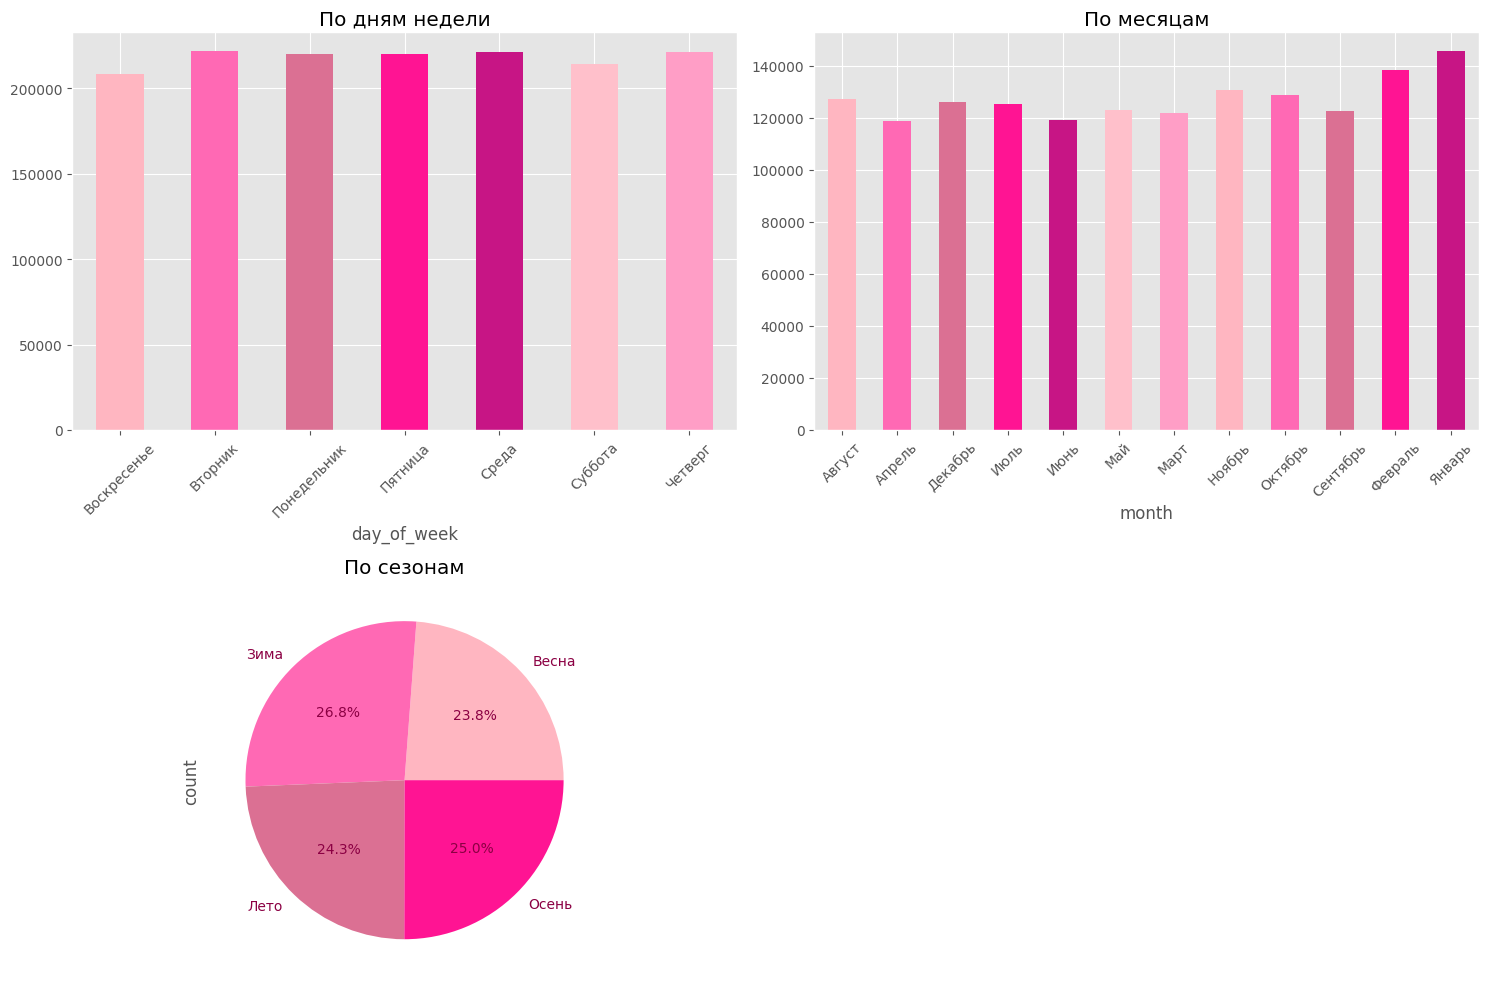

In [ ]:
# Словари для красивых названий
day_names = {0: 'Понедельник', 1: 'Вторник', 2: 'Среда',
             3: 'Четверг', 4: 'Пятница', 5: 'Суббота', 6: 'Воскресенье'}

month_names = {1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель',
               5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август',
               9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'}

season_names = {1: 'Зима', 2: 'Весна', 3: 'Лето', 4: 'Осень'}

# 1. Проверка первых записей
print("=== Первые 5 записей с новыми признаками ===")
display(data_encoded[['researchDate', 'day_of_week', 'month', 'season']].head().style
        .set_caption("Пример данных")
        .format({'day_of_week': lambda x: day_names[x],
                 'month': lambda x: month_names[x],
                 'season': lambda x: season_names[x]}))

# 2. Распределение по дням недели
day_counts = data_encoded['day_of_week'].value_counts().rename(index=day_names).sort_index()
day_percents = (day_counts/day_counts.sum()*100).round(1)

print("\n=== Распределение по дням недели ===")
day_df = pd.DataFrame({'День': day_names.values(),
                       'Количество': day_counts,
                       '%': day_percents})
display(day_df.style.bar(color='#ba5faf'))

# 3. Распределение по месяцам
month_counts = data_encoded['month'].value_counts().rename(index=month_names).sort_index()
month_percents = (month_counts/month_counts.sum()*100).round(1)

print("\n=== Распределение по месяцам ===")
month_df = pd.DataFrame({'Месяц': month_names.values(),
                         'Количество': month_counts,
                         '%': month_percents})
display(month_df.style.background_gradient(cmap='RdPu'))

# 4. Распределение по сезонам
season_counts = data_encoded['season'].value_counts().rename(index=season_names).sort_index()
season_percents = (season_counts/season_counts.sum()*100).round(1)

print("\n=== Распределение по сезонам ===")
season_df = pd.DataFrame({'Сезон': season_names.values(),
                          'Количество': season_counts,
                          '%': season_percents})
display(season_df.style.set_properties(**{'background-color': '#ffebf3',
                                         'color': '#8b0043'}))

# 5. Визуализация
plt.figure(figsize=(15, 10))

# Цветовая палитра
pink_palette = ['#ffb6c1', '#ff69b4', '#db7093', '#ff1493', '#c71585', '#ffc0cb', '#ff9ec6']

plt.subplot(2, 2, 1)
data_encoded['day_of_week'].value_counts().rename(index=day_names).sort_index().plot(
    kind='bar', color=pink_palette, title='По дням недели')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
data_encoded['month'].value_counts().rename(index=month_names).sort_index().plot(
    kind='bar', color=pink_palette, title='По месяцам')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
data_encoded['season'].value_counts().rename(index=season_names).sort_index().plot(
    kind='pie', autopct='%1.1f%%', colors=pink_palette[:4],
    title='По сезонам', textprops={'color': '#8b0043'})

plt.tight_layout()
plt.show()